# 04 Distribution Analysis

Research Question 3:

How do performance distributions change as players approach mastery?

Workflow:

1. Load `player_trajectories.csv`
2. Split each career into early (first 25%) and late (last 25%) phases
3. Compute distribution metrics (mean, std, skewness, kurtosis)
4. Plot early vs late distributions for one example player
5. Compare variability with `std_reduction = std_late / std_early`
6. Build population summary with paired tests
7. Save outputs

Outputs:

- `distribution_metrics.csv`
- `variability_comparison.csv`
- `distribution_summary.csv`
- `figures/example_distribution_overlay.png`

Trajectory input: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\processed\player_trajectories.csv
Rows loaded: 7056
Players loaded: 10


,person_id,person_name,competition_date,average_seconds,seq_index
0,2009LIUE01,Evan Liu,2009-05-30,44.77,1
1,2009LIUE01,Evan Liu,2009-08-14,33.30,2
2,2009LIUE01,Evan Liu,2010-01-30,20.28,3
3,2009LIUE01,Evan Liu,2010-01-30,21.71,4
4,2009LIUE01,Evan Liu,2010-04-18,20.91,5


Saved distribution metrics to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\distribution_metrics.csv
Saved variability comparison to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\variability_comparison.csv
Saved distribution summary to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\distribution_summary.csv

Per-player variability comparison:


,person_id,person_name,n_obs,phase_n,mean_early,mean_late,std_early,std_late,std_ratio,variability_reduction_pct,skewness_early,skewness_late,kurtosis_early,kurtosis_late
0,2011EDUA01,Eduard Esteban García Domínguez,860,215,15.223721,12.883442,8.417348,0.969133,0.115135,0.884865,13.084238,0.753466,183.377479,1.099515
1,2012PARK03,Max Park,617,154,8.513247,5.708701,2.607982,0.400938,0.153735,0.846265,2.034403,1.623096,4.571006,6.129649
2,2012MAHV01,Paul Mahvi,701,175,10.701714,8.097314,3.743955,0.587667,0.156964,0.843036,4.154653,0.551174,23.726398,0.671653
3,2009LIUE01,Evan Liu,700,175,12.830057,9.010343,3.794821,0.765819,0.201806,0.798194,4.761485,-0.004741,32.823985,0.611709
4,2009PROV01,Matteo Provasi,750,187,15.043422,11.298021,3.471326,0.751403,0.216460,0.783540,4.051347,0.651517,21.906316,1.141853
5,2010HULL01,Katie Hull,684,171,10.562573,8.913509,1.808479,0.587151,0.324666,0.675334,4.573325,1.341001,26.370187,4.673673
6,2013WALL03,Daniel Wallin,711,177,10.369887,8.050508,1.980837,0.678043,0.342301,0.657699,1.506124,0.721588,2.646490,0.592275
7,2014ZAKR01,Karol Zakrzewski,648,162,10.504074,8.851914,1.542823,0.576513,0.373674,0.626326,2.328930,0.026033,8.071640,-0.337482
8,2013ROGA02,Przemysław Rogalski,626,156,14.441795,11.434295,1.915331,0.744072,0.388482,0.611518,1.442694,0.536843,2.249429,0.673443
9,2010ROSE03,Dennis Rosero,759,189,16.406614,14.335556,2.074556,0.819799,0.395168,0.604832,1.708799,0.568179,3.650289,1.147839



Population summary:


,metric,value
0,players_analyzed,10.000000
1,mean_std_early,3.135746
2,mean_std_late,0.688054
3,mean_std_ratio,0.266839
4,mean_variability_reduction_pct,0.733161
5,share_with_reduced_variability,1.000000
6,paired_t_stat,3.980065
7,paired_t_pvalue,0.003205
8,wilcoxon_stat,0.000000
9,wilcoxon_pvalue,0.001953



Average early skewness and kurtosis:
skewness_early    3.964600
skewness_late     0.676815
dtype: float64
kurtosis_early    30.939322
kurtosis_late      1.640413
dtype: float64


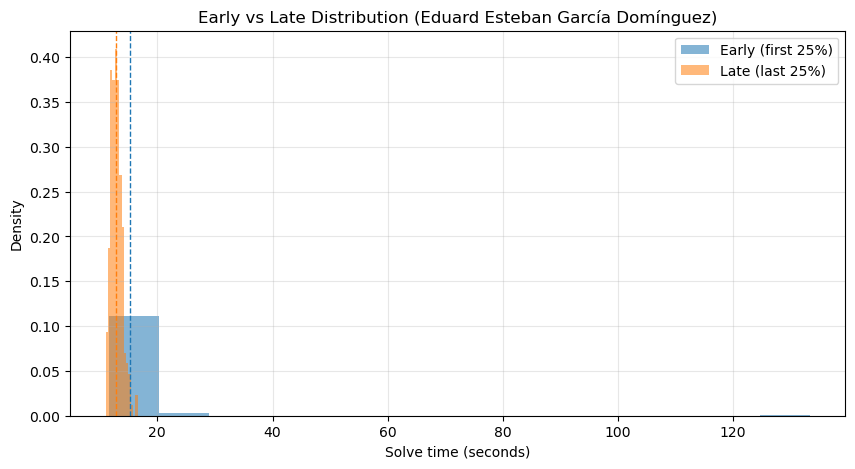


Saved example distribution figure to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\figures\example_distribution_overlay.png
Example player: Eduard Esteban García Domínguez (2011EDUA01)


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import kurtosis, skew, ttest_rel, wilcoxon

ROOT = Path.cwd()
if not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loading import processed_data_dir, results_data_dir

experiment_name = "case_study_333_10players"
processed_dir = processed_data_dir(ROOT, experiment_name=experiment_name)
results_dir = results_data_dir(ROOT, experiment_name=experiment_name)
figures_dir = results_dir / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

trajectories_path = processed_dir / "player_trajectories.csv"
metrics_path = results_dir / "distribution_metrics.csv"
comparison_path = results_dir / "variability_comparison.csv"
summary_path = results_dir / "distribution_summary.csv"
example_plot_path = figures_dir / "example_distribution_overlay.png"

print(f"Trajectory input: {trajectories_path}")
print(f"Results dir: {results_dir}")
if not trajectories_path.exists():
    raise FileNotFoundError(f"Missing trajectory file: {trajectories_path}")

player_trajectories = pd.read_csv(trajectories_path, parse_dates=["competition_date"])
player_trajectories = player_trajectories.sort_values(["person_id", "seq_index"]).reset_index(drop=True)

time_col = "average_seconds"
if time_col not in player_trajectories.columns:
    raise ValueError(f"Expected column '{time_col}' not found in player_trajectories.csv")

print(f"Rows loaded: {len(player_trajectories)}")
print(f"Players loaded: {player_trajectories['person_id'].nunique()}")
display(player_trajectories.head())


metrics_rows = []
comparison_rows = []
skipped_players = []

for person_id, group in player_trajectories.groupby("person_id", sort=False):
    group = group.sort_values("seq_index").reset_index(drop=True)
    player_name = group["person_name"].iloc[0]
    n_obs = len(group)
    phase_n = n_obs // 4

    if phase_n < 3:
        skipped_players.append({"person_id": person_id, "reason": "too_few_observations"})
        continue

    early = group.iloc[:phase_n].copy()
    late = group.iloc[-phase_n:].copy()

    def phase_stats(values):
        values = np.asarray(values, dtype=float)
        return {
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else float("nan"),
            "skewness": float(skew(values, bias=False)) if len(values) > 2 else float("nan"),
            "kurtosis": float(kurtosis(values, fisher=True, bias=False)) if len(values) > 3 else float("nan"),
        }

    early_stats = phase_stats(early[time_col].to_numpy())
    late_stats = phase_stats(late[time_col].to_numpy())

    metrics_rows.append({
        "person_id": person_id,
        "person_name": player_name,
        "phase": "early",
        "n_phase": int(len(early)),
        **early_stats,
    })
    metrics_rows.append({
        "person_id": person_id,
        "person_name": player_name,
        "phase": "late",
        "n_phase": int(len(late)),
        **late_stats,
    })

    std_early = early_stats["std"]
    std_late = late_stats["std"]
    std_ratio = float(std_late / std_early) if np.isfinite(std_early) and std_early > 0 else float("nan")
    variability_reduction_pct = float(1 - std_ratio) if np.isfinite(std_ratio) else float("nan")

    comparison_rows.append({
        "person_id": person_id,
        "person_name": player_name,
        "n_obs": int(n_obs),
        "phase_n": int(phase_n),
        "mean_early": early_stats["mean"],
        "mean_late": late_stats["mean"],
        "std_early": std_early,
        "std_late": std_late,
        "std_ratio": std_ratio,
        "variability_reduction_pct": variability_reduction_pct,
        "skewness_early": early_stats["skewness"],
        "skewness_late": late_stats["skewness"],
        "kurtosis_early": early_stats["kurtosis"],
        "kurtosis_late": late_stats["kurtosis"],
    })


distribution_metrics = pd.DataFrame(metrics_rows)
variability_comparison = pd.DataFrame(comparison_rows)

if not distribution_metrics.empty:
    distribution_metrics = distribution_metrics.sort_values(["person_id", "phase"]).reset_index(drop=True)
if not variability_comparison.empty:
    variability_comparison = variability_comparison.sort_values("std_ratio").reset_index(drop=True)

summary_rows = []
if not variability_comparison.empty:
    summary_rows.extend(
        [
            {"metric": "players_analyzed", "value": float(len(variability_comparison))},
            {"metric": "mean_std_early", "value": float(np.nanmean(variability_comparison["std_early"]))},
            {"metric": "mean_std_late", "value": float(np.nanmean(variability_comparison["std_late"]))},
            {"metric": "mean_std_ratio", "value": float(np.nanmean(variability_comparison["std_ratio"]))},
            {"metric": "mean_variability_reduction_pct", "value": float(np.nanmean(variability_comparison["variability_reduction_pct"]))},
            {"metric": "share_with_reduced_variability", "value": float(np.mean(variability_comparison["std_ratio"] < 1))},
        ]
    )

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv(summary_path, index=False)
variability_comparison.to_csv(comparison_path, index=False)
distribution_metrics.to_csv(metrics_path, index=False)

print(f"Saved distribution metrics to: {metrics_path}")
print(f"Saved variability comparison to: {comparison_path}")
print(f"Saved summary to: {summary_path}")

## Interpretation Guide

Key interpretation targets for RQ3:

- Lower `mean` in late phase indicates better average performance.
- `std_reduction < 1` indicates variability shrank toward mastery.
- Skewness moving toward 0 suggests more symmetric distributions.
- Lower excess kurtosis suggests fewer heavy-tail outliers.
- Significant paired-test p-values support a systematic population-level change in variability.